In [1]:
# Cell 1 – Imports & Load CSV
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)

df = pd.read_csv("datasets/research_student.csv")
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (221, 24)

Columns: ['Branch', 'Marks[10th]', 'Marks[12th]', 'Gender', 'Board[10th]', 'Board[12th]', 'Category', 'GPA 1', 'Rank', 'Normalized Rank', 'CGPA', 'Current Back', 'Ever Back', 'GPA 2', 'GPA 3', 'GPA 4', 'GPA 5', 'GPA 6', 'Olympiads Qualified', 'Technical Projects', 'Tech Quiz', 'Engg. Coaching', 'NTSE Scholarships', 'Miscellany Tech Events']


,Branch,Marks[10th],Marks[12th],Gender,Board[10th],Board[12th],Category,GPA 1,Rank,Normalized Rank,CGPA,Current Back,Ever Back,GPA 2,GPA 3,GPA 4,GPA 5,GPA 6,Olympiads Qualified,Technical Projects,Tech Quiz,Engg. Coaching,NTSE Scholarships,Miscellany Tech Events
0,CIVIL,77.57,64.6,Male,BSEB Patna,BSEB Patna,OBC,6.29,44718.0,15.970714,6.02,1.0,4.0,6.12,5.94,5.41,6.25,6.13,1.0,4.0,3.0,2.0,0.0,5.0
1,CSE,86.40,71.8,Male,CBSE,CBSE,GEN,6.47,24222.0,8.650714,6.10,1.0,7.0,6.12,5.88,5.53,6.44,6.19,2.0,2.0,0.0,1.0,0.0,4.0
2,CSE,88.14,78.0,Male,ICSE,ICSE,GEN,7.35,24723.0,8.829643,6.65,1.0,1.0,6.35,6.54,6.41,6.50,6.69,1.0,1.0,3.0,0.0,0.0,5.0
3,CSE,65.40,59.8,Female,CBSE,CBSE,ST,6.41,232157.0,82.913214,6.09,1.0,11.0,6.00,5.71,5.24,5.88,6.25,2.0,0.0,2.0,2.0,0.0,1.0
4,CSE,81.00,74.0,Male,CBSE,CBSE,GEN,6.80,23252.0,8.304286,6.13,1.0,0.0,6.06,5.88,6.00,5.93,5.44,2.0,0.0,2.0,2.0,0.0,1.0


Duplicate rows: 0

Quality Report:


,missing_count,missing_pct,n_unique,dtype
Board[10th],1,0.45,41,object
Board[12th],1,0.45,48,object
Branch,1,0.45,8,object
CGPA,1,0.45,151,float64
Category,1,0.45,5,object
Current Back,1,0.45,3,float64
Engg. Coaching,1,0.45,11,float64
Ever Back,2,0.90,15,float64
GPA 1,1,0.45,71,float64
GPA 2,1,0.45,68,float64


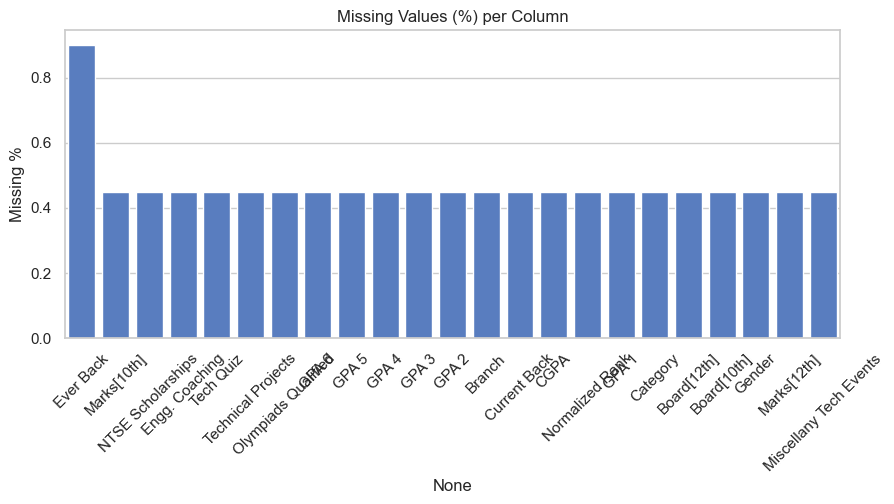

In [ ]:
# Cell 2 – Data Quality Audit
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

quality = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct,
    "n_unique": df.nunique(dropna=False),
    "dtype": df.dtypes
})

print("Duplicate rows:", df.duplicated().sum())
print("\nQuality Report:")
display(quality)

cols_with_missing = missing_pct[missing_pct > 0]

if len(cols_with_missing):
    plt.figure(figsize=(10,4))
    sns.barplot(x=cols_with_missing.index, y=cols_with_missing.values)
    plt.title("Missing Values (%) per Column")
    plt.xticks(rotation=45)
    plt.ylabel("Missing %")
    plt.show()
else:
    print("No missing values")w

In [3]:
# Cell 3 – Descriptive Statistics
print("Numeric Summary")
display(df.describe().round(2))

print("\nCategorical Summary")
display(df.describe(include="object"))

Numeric Summary


,Marks[10th],Marks[12th],GPA 1,Rank,Normalized Rank,CGPA,Current Back,Ever Back,GPA 2,GPA 3,GPA 4,GPA 5,GPA 6,Olympiads Qualified,Technical Projects,Tech Quiz,Engg. Coaching,NTSE Scholarships,Miscellany Tech Events
count,220.00,220.00,220.00,221.00,220.00,220.00,220.00,219.00,220.00,220.00,220.00,220.00,220.00,220.0,220.00,220.00,220.00,220.00,220.00
mean,84.31,77.78,7.53,42312.12,14.73,7.20,0.08,1.44,7.27,7.17,7.29,7.89,7.55,3.6,1.85,1.84,2.97,0.69,1.50
std,8.52,9.04,4.60,38503.69,12.53,0.70,0.27,2.66,4.43,4.13,4.51,5.10,0.96,2.1,1.37,1.38,2.05,1.34,2.22
min,53.70,56.80,5.76,11814.00,4.22,5.89,0.00,0.00,5.76,4.88,4.90,5.50,4.56,0.0,0.00,0.00,0.00,0.00,0.00
25%,79.00,71.55,6.71,23949.00,8.54,6.64,0.00,0.00,6.42,6.32,6.44,6.81,6.86,2.0,1.00,1.00,1.00,0.00,0.00
50%,86.55,79.10,7.18,30080.00,10.69,7.12,0.00,0.00,6.88,6.82,6.96,7.63,7.50,4.0,2.00,2.00,3.00,0.00,0.00
75%,91.00,85.25,7.76,41527.00,14.72,7.70,0.00,2.00,7.47,7.41,7.48,8.25,8.19,5.0,3.00,3.00,4.00,1.00,4.00
max,96.60,96.50,74.70,279839.00,99.94,9.01,1.00,13.00,71.80,67.20,72.90,81.90,9.81,10.0,5.00,7.00,10.00,7.00,5.00



Categorical Summary


,Branch,Gender,Board[10th],Board[12th],Category
count,220,220,220,220,220
unique,7,2,40,47,4
top,ECE,Male,CBSE,CBSE,GEN
freq,52,174,103,116,161


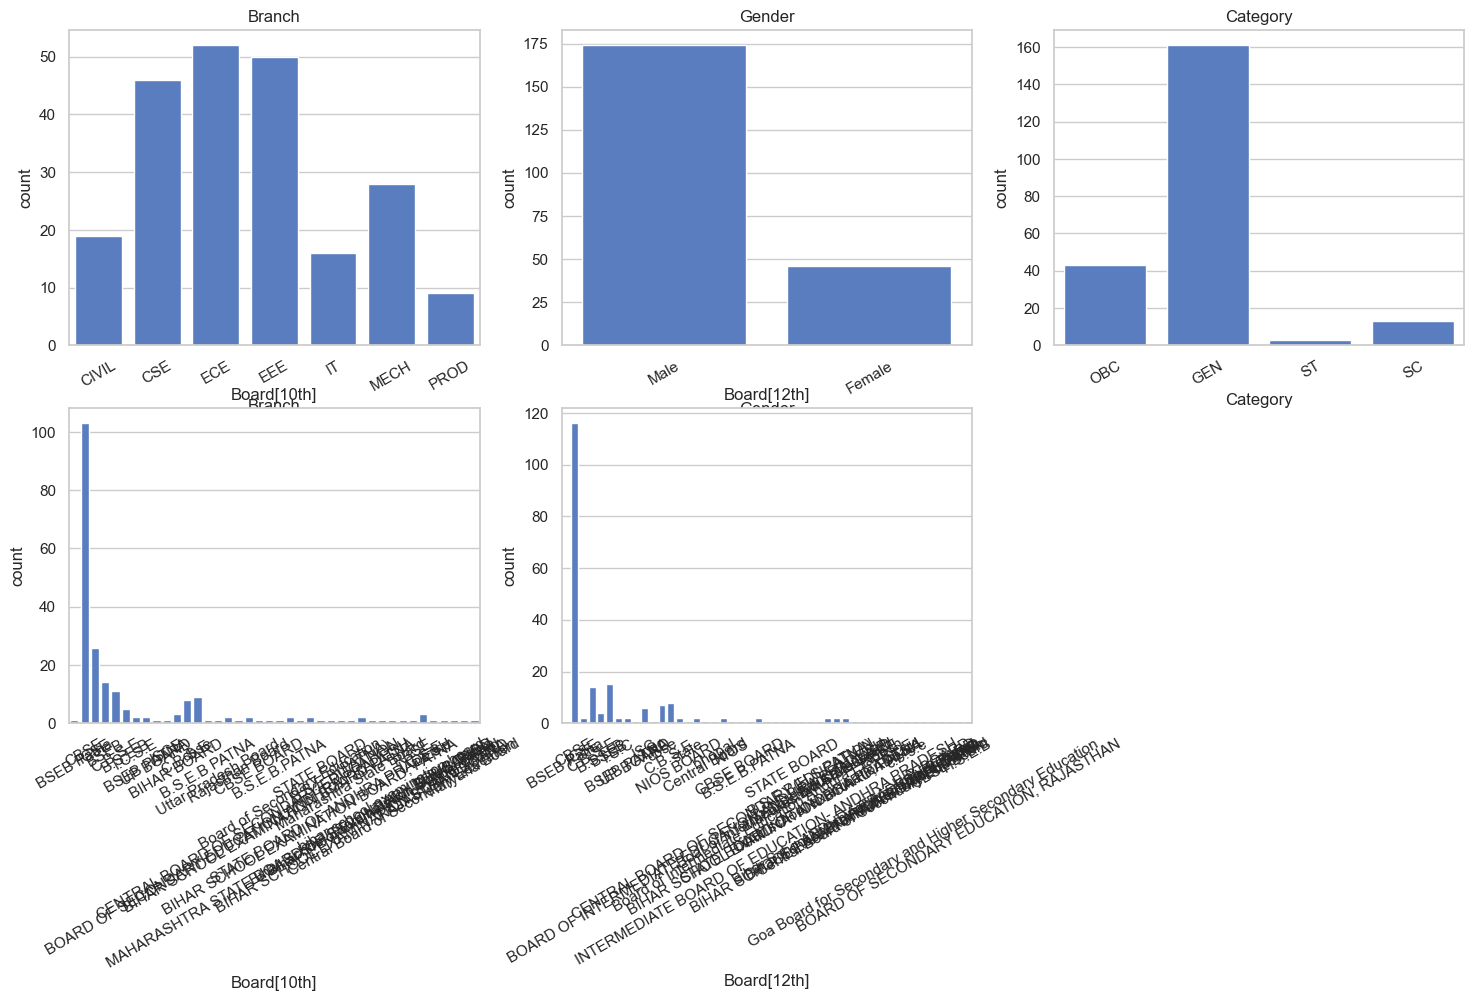

In [4]:
# Cell 4 – Categorical Distributions
cat_cols = ["Branch","Gender","Category","Board[10th]","Board[12th]"]

fig, axes = plt.subplots(2,3, figsize=(18,9))
axes = axes.flatten()

for i,col in enumerate(cat_cols):
    sns.countplot(data=df,x=col,ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x",rotation=30)

axes[-1].axis("off")
plt.show()

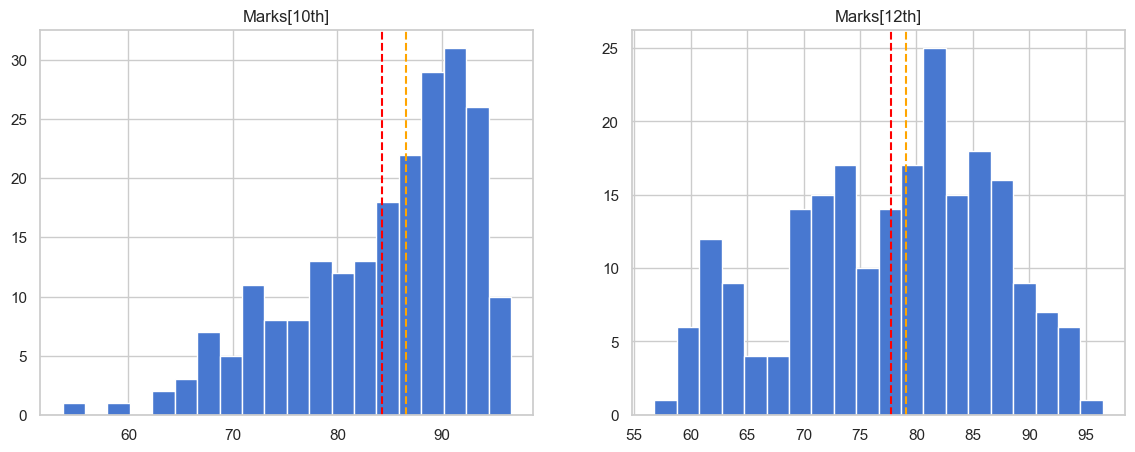

In [5]:
# Cell 5 – Marks Distribution
fig, axes = plt.subplots(1,2, figsize=(14,5))

for ax,col in zip(axes,["Marks[10th]","Marks[12th]"]):
    data = df[col].dropna()
    ax.hist(data,bins=20)
    ax.axvline(data.mean(),color="red",linestyle="--")
    ax.axvline(data.median(),color="orange",linestyle="--")
    ax.set_title(col)

plt.show()

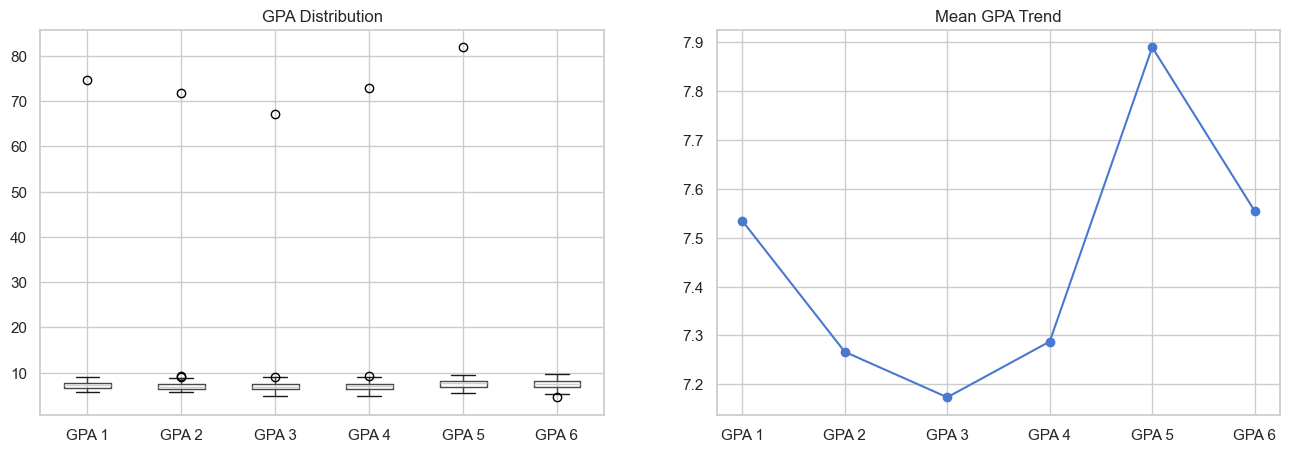

In [6]:
# Cell 6 – Semester GPA Trend
gpa_cols = ["GPA 1","GPA 2","GPA 3","GPA 4","GPA 5","GPA 6"]
gpa_cols = [c for c in gpa_cols if c in df.columns]

gpa_data = df[gpa_cols].apply(pd.to_numeric,errors="coerce")

fig, axes = plt.subplots(1,2,figsize=(16,5))

gpa_data.boxplot(ax=axes[0])
axes[0].set_title("GPA Distribution")

gpa_means = gpa_data.mean()
axes[1].plot(gpa_means.index,gpa_means.values,marker="o")
axes[1].set_title("Mean GPA Trend")

plt.show()

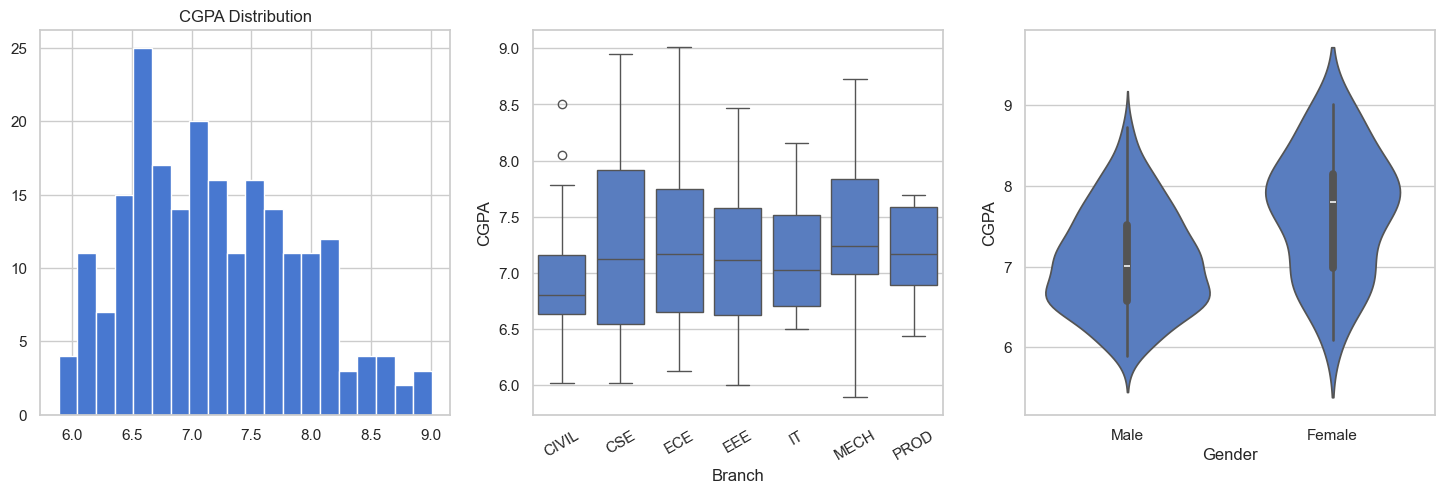

In [7]:
# Cell 7 – CGPA Distribution
fig, axes = plt.subplots(1,3, figsize=(18,5))

cgpa = pd.to_numeric(df["CGPA"],errors="coerce").dropna()
axes[0].hist(cgpa,bins=20)
axes[0].set_title("CGPA Distribution")

sns.boxplot(data=df,x="Branch",y="CGPA",ax=axes[1])
axes[1].tick_params(axis="x",rotation=30)

sns.violinplot(data=df,x="Gender",y="CGPA",ax=axes[2])

plt.show()

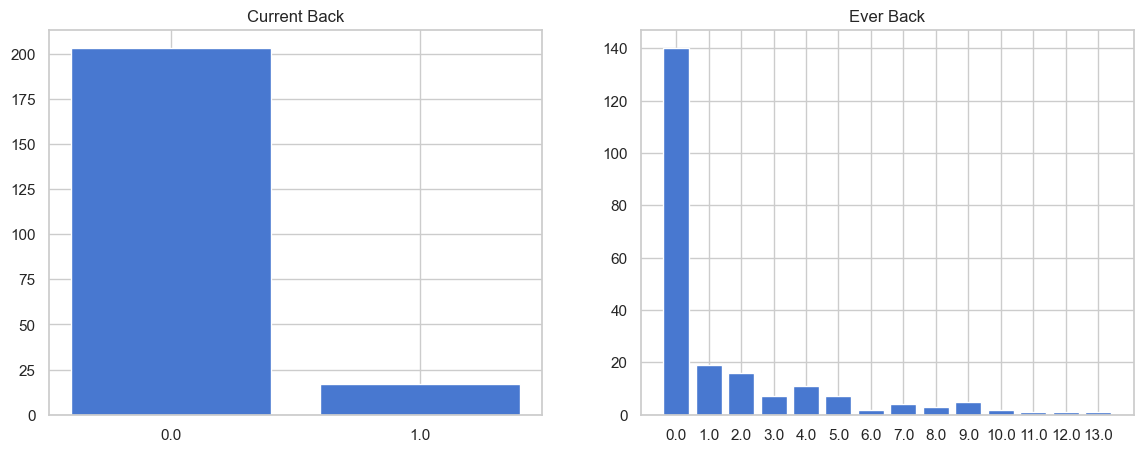

In [8]:
# Cell 8 – Backlog Analysis
fig, axes = plt.subplots(1,2, figsize=(14,5))

for ax,col in zip(axes,["Current Back","Ever Back"]):
    data = pd.to_numeric(df[col],errors="coerce")
    counts = data.value_counts().sort_index()
    ax.bar(counts.index.astype(str),counts.values)
    ax.set_title(col)

plt.show()

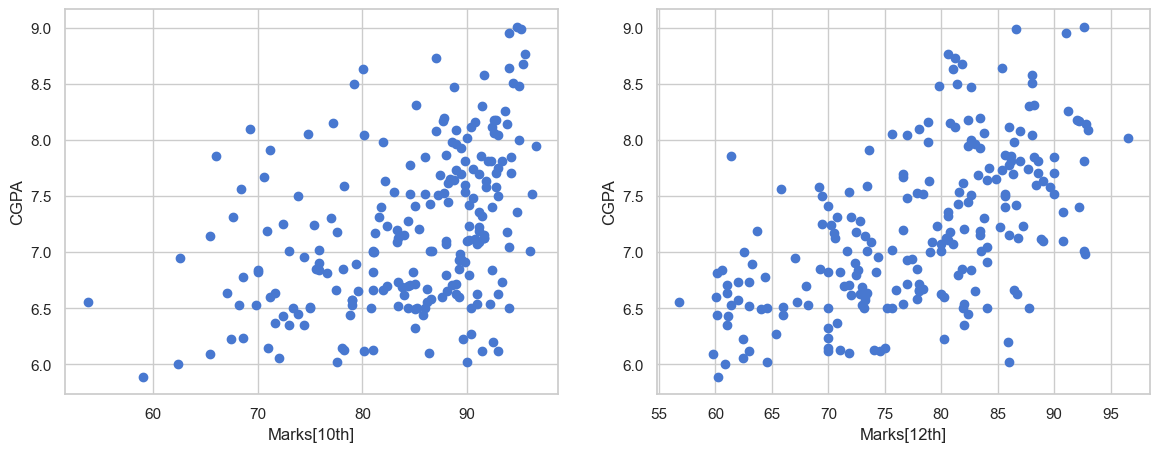

In [9]:
# Cell 9 – Marks vs CGPA
fig, axes = plt.subplots(1,2, figsize=(14,5))

for ax,col in zip(axes,["Marks[10th]","Marks[12th]"]):
    x = pd.to_numeric(df[col],errors="coerce")
    y = pd.to_numeric(df["CGPA"],errors="coerce")
    ax.scatter(x,y)
    ax.set_xlabel(col)
    ax.set_ylabel("CGPA")

plt.show()

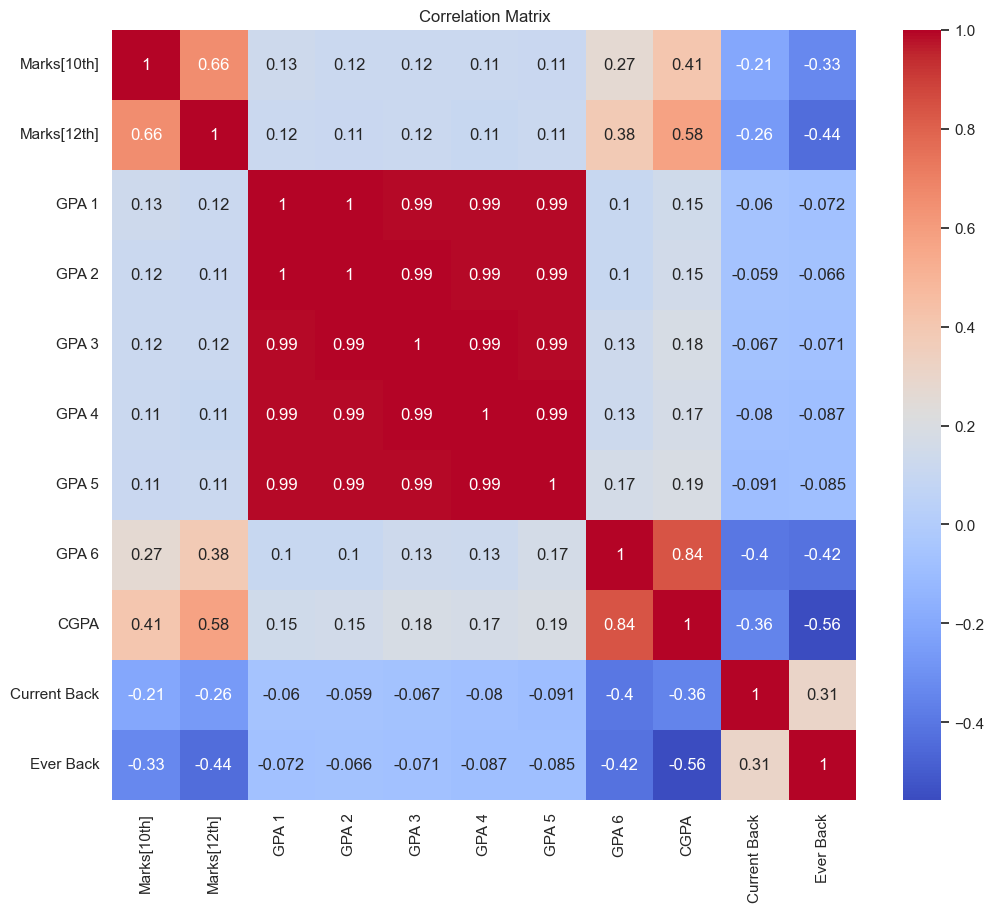

In [10]:
# Cell 10 – Correlation Heatmap
num_cols = ["Marks[10th]","Marks[12th]","GPA 1","GPA 2","GPA 3","GPA 4",
            "GPA 5","GPA 6","CGPA","Current Back","Ever Back"]

num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].apply(pd.to_numeric,errors="coerce").corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

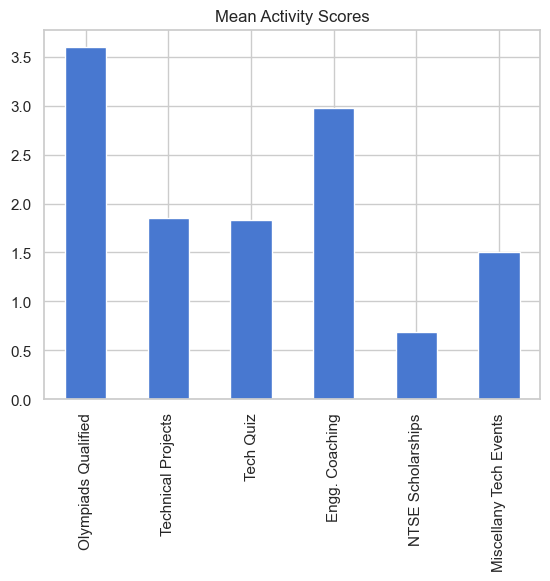

In [11]:
# Cell 11 – Activity Analysis
activity_cols = ["Olympiads Qualified","Technical Projects","Tech Quiz",
                 "Engg. Coaching","NTSE Scholarships","Miscellany Tech Events"]

activity_cols = [c for c in activity_cols if c in df.columns]

act_df = df[activity_cols].apply(pd.to_numeric,errors="coerce")

act_df.mean().plot(kind="bar")
plt.title("Mean Activity Scores")
plt.show()

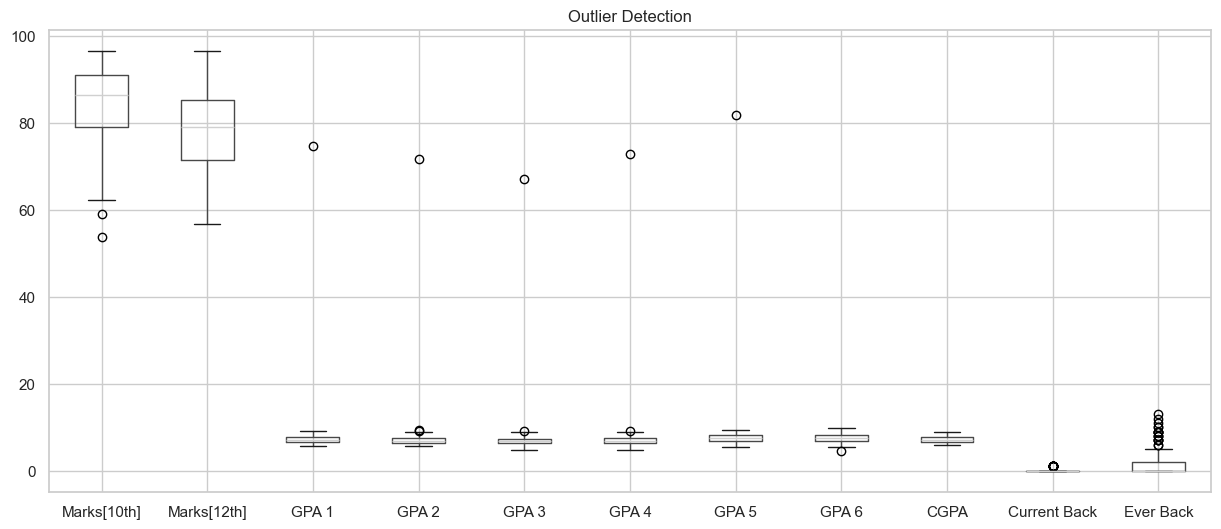

In [12]:
# Cell 12 – Outlier Detection
num_df = df[num_cols].apply(pd.to_numeric,errors="coerce")

num_df.boxplot(figsize=(15,6))
plt.title("Outlier Detection")
plt.show()

In [13]:
# Cell 13 – High vs Low CGPA Segment
seg = df.copy()

for c in num_cols:
    seg[c] = pd.to_numeric(seg[c],errors="coerce")

median = seg["CGPA"].median()

seg["Segment"] = np.where(seg["CGPA"] >= median,"High CGPA","Low CGPA")

seg.groupby("Segment")[num_cols].mean()

,Marks[10th],Marks[12th],GPA 1,GPA 2,GPA 3,GPA 4,GPA 5,GPA 6,CGPA,Current Back,Ever Back
Segment,,,,,,,,,,,
High CGPA,87.011727,82.293545,8.348455,8.035273,8.015091,8.147364,8.983909,8.207977,7.776782,0.000000,0.072727
Low CGPA,81.603182,73.272909,6.720364,6.497727,6.331909,6.427745,6.794750,6.901136,6.622155,0.154545,2.825688


Feature means by CGPA segment:


,Marks[10th],Marks[12th],GPA 1,GPA 2,GPA 3,GPA 4,GPA 5,GPA 6,CGPA,Current Back,Ever Back
Segment,,,,,,,,,,,
High CGPA,87.01,82.29,8.35,8.04,8.02,8.15,8.98,8.21,7.78,0.00,0.07
Low CGPA,81.60,73.27,6.72,6.50,6.33,6.43,6.79,6.90,6.62,0.15,2.83


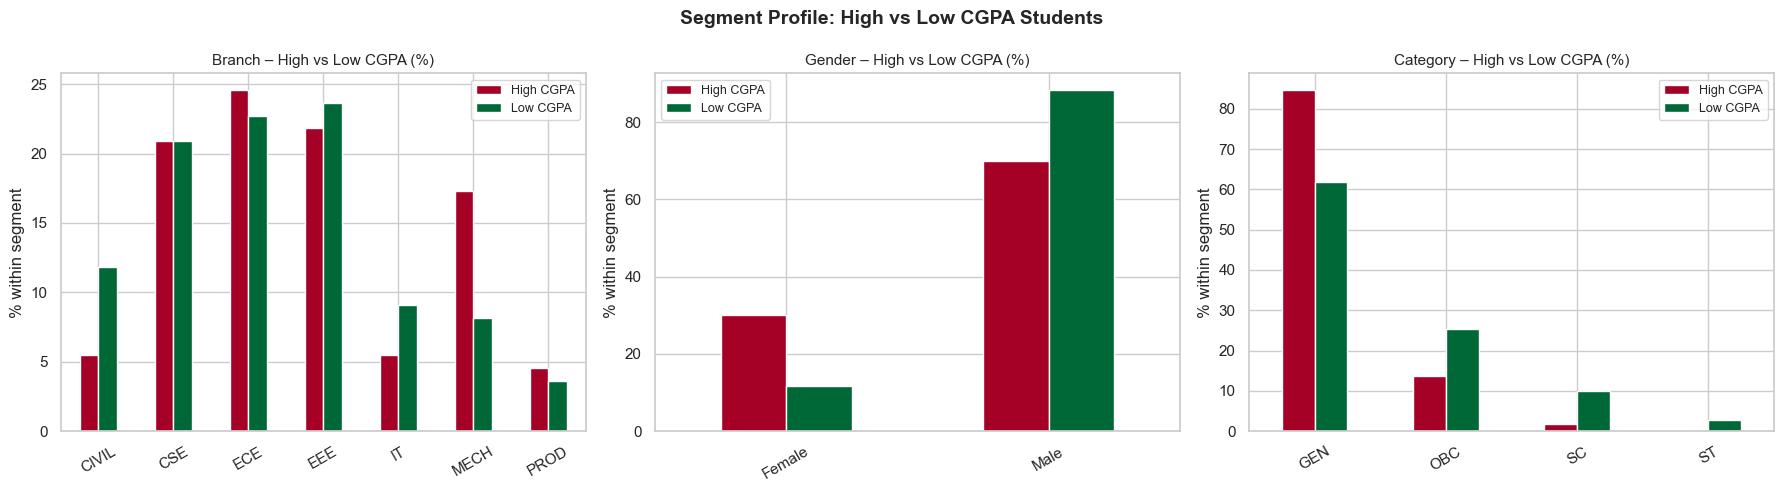

In [14]:
# Numeric means per segment
print("Feature means by CGPA segment:")
display(seg.groupby("Segment")[num_cols].mean().round(2))


# Categorical breakdown per segment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["Branch", "Gender", "Category"]):
    cross = pd.crosstab(seg[col], seg["Segment"], normalize="columns") * 100
    
    cross.plot(kind="bar", ax=ax, colormap="RdYlGn", edgecolor="white")
    
    ax.set_title(f"{col} – High vs Low CGPA (%)", fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("% within segment")
    ax.set_xlabel("")
    ax.legend(fontsize=9)

plt.suptitle("Segment Profile: High vs Low CGPA Students", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()